In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import altair as alt
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest

In [6]:
df = pd.read_excel('/content/financial_anomaly_data.xlsx')

In [7]:
df.head()

,Timestamp,TransactionID,AccountID,Amount,Merchant,TransactionType,Location
0,2023-01-01 08:00:00,TXN1127,ACC4,95071.92,MerchantH,Purchase,Tokyo
1,2023-01-01 08:01:00,TXN1639,ACC10,15607.89,MerchantH,Purchase,London
2,2023-01-01 08:02:00,TXN872,ACC8,65092.34,MerchantE,Withdrawal,London
3,2023-01-01 08:03:00,TXN1438,ACC6,87.87,MerchantE,Purchase,London
4,2023-01-01 08:04:00,TXN1338,ACC6,716.56,MerchantI,Purchase,Los Angeles


### 3.1 Data Preparation

In [8]:
df.shape

(216960, 7)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216960 entries, 0 to 216959
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Timestamp        216960 non-null  object 
 1   TransactionID    216960 non-null  object 
 2   AccountID        216960 non-null  object 
 3   Amount           216960 non-null  float64
 4   Merchant         216960 non-null  object 
 5   TransactionType  216960 non-null  object 
 6   Location         216960 non-null  object 
dtypes: float64(1), object(6)
memory usage: 11.6+ MB


In [11]:
df.describe()


,Timestamp,Amount
count,216960,216960.000000
mean,2023-04-27 16:24:59.203539968,50090.025108
min,2023-01-01 08:00:00,10.510000
25%,2023-02-21 23:59:45,25061.242500
50%,2023-04-14 15:59:30,50183.980000
75%,2023-05-29 07:59:15,75080.460000
max,2023-12-05 23:59:00,978942.260000
std,NaN,29097.905016


In [10]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216960 entries, 0 to 216959
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Timestamp        216960 non-null  datetime64[ns]
 1   TransactionID    216960 non-null  object        
 2   AccountID        216960 non-null  object        
 3   Amount           216960 non-null  float64       
 4   Merchant         216960 non-null  object        
 5   TransactionType  216960 non-null  object        
 6   Location         216960 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(5)
memory usage: 11.6+ MB


In [12]:
df['Year'] = df['Timestamp'].dt.year
df['Month'] = df['Timestamp'].dt.month
df['Day'] = df['Timestamp'].dt.day
df['Hour'] = df['Timestamp'].dt.hour
df['Minute'] = df['Timestamp'].dt.minute
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek # Monday=0, Sunday=6
df['DayOfYear'] = df['Timestamp'].dt.dayofyear
df.head()

,Timestamp,TransactionID,AccountID,Amount,Merchant,TransactionType,Location,Year,Month,Day,Hour,Minute,DayOfWeek,DayOfYear
0,2023-01-01 08:00:00,TXN1127,ACC4,95071.92,MerchantH,Purchase,Tokyo,2023,1,1,8,0,6,1
1,2023-01-01 08:01:00,TXN1639,ACC10,15607.89,MerchantH,Purchase,London,2023,1,1,8,1,6,1
2,2023-01-01 08:02:00,TXN872,ACC8,65092.34,MerchantE,Withdrawal,London,2023,1,1,8,2,6,1
3,2023-01-01 08:03:00,TXN1438,ACC6,87.87,MerchantE,Purchase,London,2023,1,1,8,3,6,1
4,2023-01-01 08:04:00,TXN1338,ACC6,716.56,MerchantI,Purchase,Los Angeles,2023,1,1,8,4,6,1


In [13]:
missing = df.isna().sum().sort_values(ascending=False)
print("Missing counts:\n", missing[missing>0])


Missing counts:
 Series([], dtype: int64)


In [14]:
dups = df.duplicated().sum()
print("Exact duplicate rows:", dups)
df = df.drop_duplicates()

Exact duplicate rows: 0


In [15]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
if 'TransactionID' in categorical_cols:
    categorical_cols.remove('TransactionID')

print("Categorical columns to be processed:", categorical_cols)

for col in categorical_cols:
    print(f"\nUnique values for column '{col}':")
    print(df[col].value_counts())


Categorical columns to be processed: ['AccountID', 'Merchant', 'TransactionType', 'Location']

Unique values for column 'AccountID':
AccountID
ACC15    14701
ACC5     14630
ACC7     14581
ACC2     14553
ACC9     14527
ACC14    14458
ACC4     14456
ACC11    14446
ACC13    14421
ACC12    14421
ACC8     14402
ACC1     14365
ACC10    14362
ACC6     14352
ACC3     14285
Name: count, dtype: int64

Unique values for column 'Merchant':
Merchant
MerchantF    21924
MerchantG    21891
MerchantD    21820
MerchantB    21766
MerchantI    21752
MerchantA    21699
MerchantJ    21654
MerchantE    21543
MerchantH    21518
MerchantC    21393
Name: count, dtype: int64

Unique values for column 'TransactionType':
TransactionType
Transfer      72793
Purchase      72235
Withdrawal    71932
Name: count, dtype: int64

Unique values for column 'Location':
Location
San Francisco    43613
New York         43378
London           43343
Los Angeles      43335
Tokyo            43291
Name: count, dtype: int64


In [16]:
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df.shape


(216960, 39)

In [17]:
df.head()

,Timestamp,TransactionID,Amount,Year,Month,Day,Hour,Minute,DayOfWeek,DayOfYear,...,Merchant_MerchantG,Merchant_MerchantH,Merchant_MerchantI,Merchant_MerchantJ,TransactionType_Transfer,TransactionType_Withdrawal,Location_Los Angeles,Location_New York,Location_San Francisco,Location_Tokyo
0,2023-01-01 08:00:00,TXN1127,95071.92,2023,1,1,8,0,6,1,...,False,True,False,False,False,False,False,False,False,True
1,2023-01-01 08:01:00,TXN1639,15607.89,2023,1,1,8,1,6,1,...,False,True,False,False,False,False,False,False,False,False
2,2023-01-01 08:02:00,TXN872,65092.34,2023,1,1,8,2,6,1,...,False,False,False,False,False,True,False,False,False,False
3,2023-01-01 08:03:00,TXN1438,87.87,2023,1,1,8,3,6,1,...,False,False,False,False,False,False,False,False,False,False
4,2023-01-01 08:04:00,TXN1338,716.56,2023,1,1,8,4,6,1,...,False,False,True,False,False,False,True,False,False,False


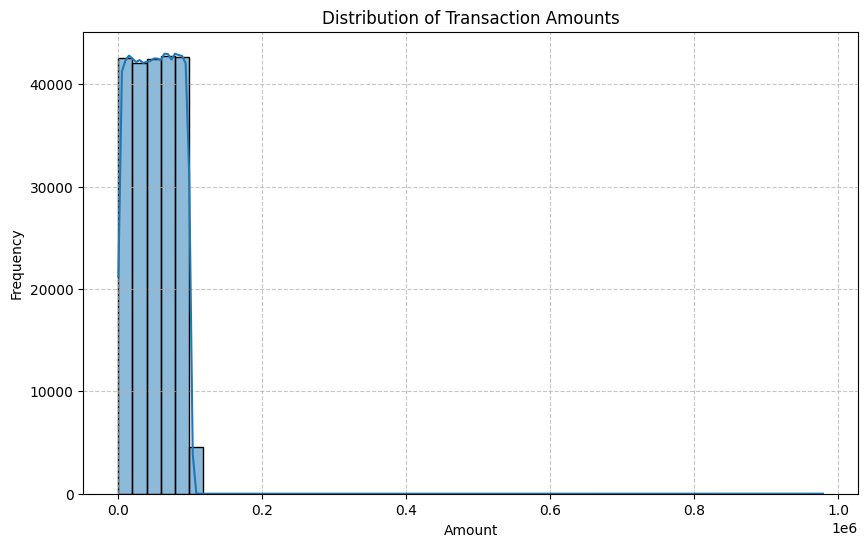

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

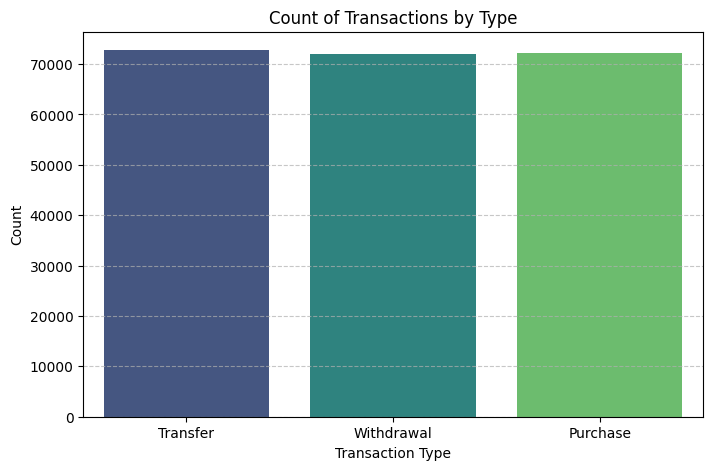

In [19]:
transaction_type_counts = df[['TransactionType_Transfer', 'TransactionType_Withdrawal']].sum().reset_index()
transaction_type_counts.columns = ['TransactionType', 'Count']
transaction_type_counts['TransactionType'] = transaction_type_counts['TransactionType'].replace({
    'TransactionType_Transfer': 'Transfer',
    'TransactionType_Withdrawal': 'Withdrawal'
})

purchase_count = len(df) - transaction_type_counts['Count'].sum()
purchase_row = pd.DataFrame([{'TransactionType': 'Purchase', 'Count': purchase_count}])
transaction_type_counts = pd.concat([transaction_type_counts, purchase_row], ignore_index=True)

plt.figure(figsize=(8, 5))
sns.barplot(x='TransactionType', y='Count', data=transaction_type_counts, palette='viridis')
plt.title('Count of Transactions by Type')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

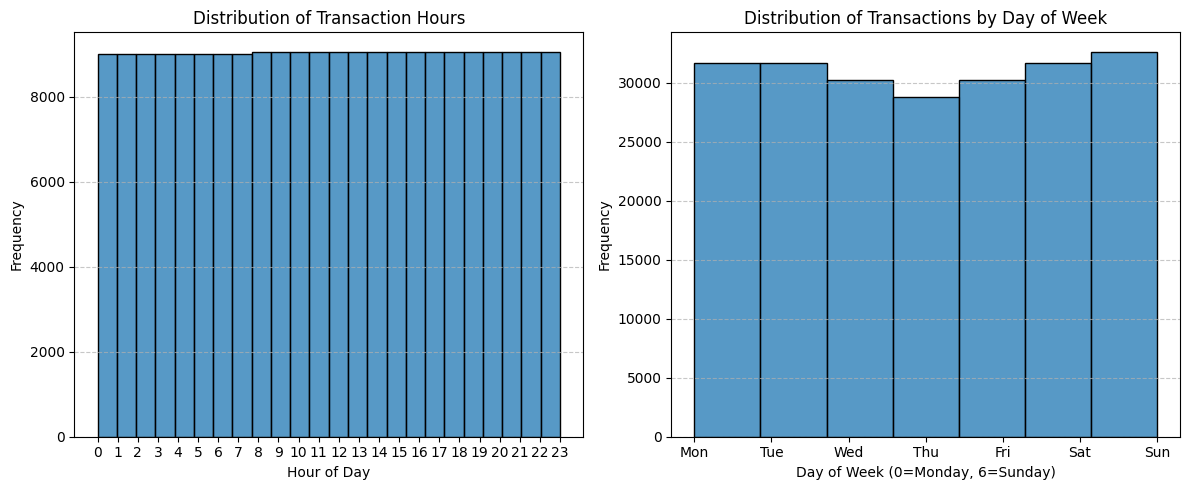

In [20]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Hour'], bins=24, kde=False, palette='viridis')
plt.title('Distribution of Transaction Hours')
plt.xlabel('Hour of Day')
plt.ylabel('Frequency')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
sns.histplot(df['DayOfWeek'], bins=7, kde=False, palette='viridis')
plt.title('Distribution of Transactions by Day of Week')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Frequency')
plt.xticks(range(0, 7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

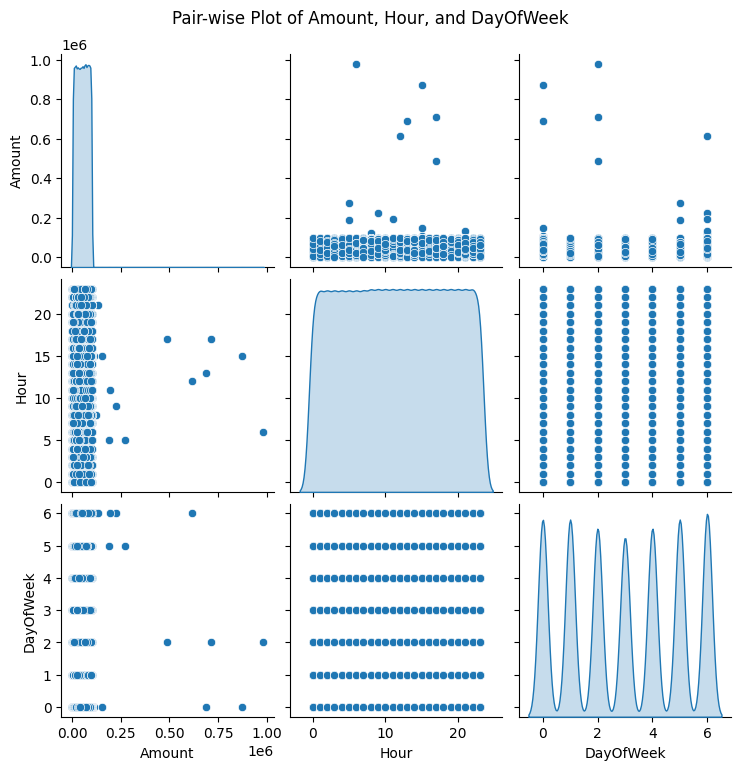

In [21]:
sns.pairplot(df[['Amount', 'Hour', 'DayOfWeek']], diag_kind='kde')
plt.suptitle('Pair-wise Plot of Amount, Hour, and DayOfWeek', y=1.02)
plt.show()

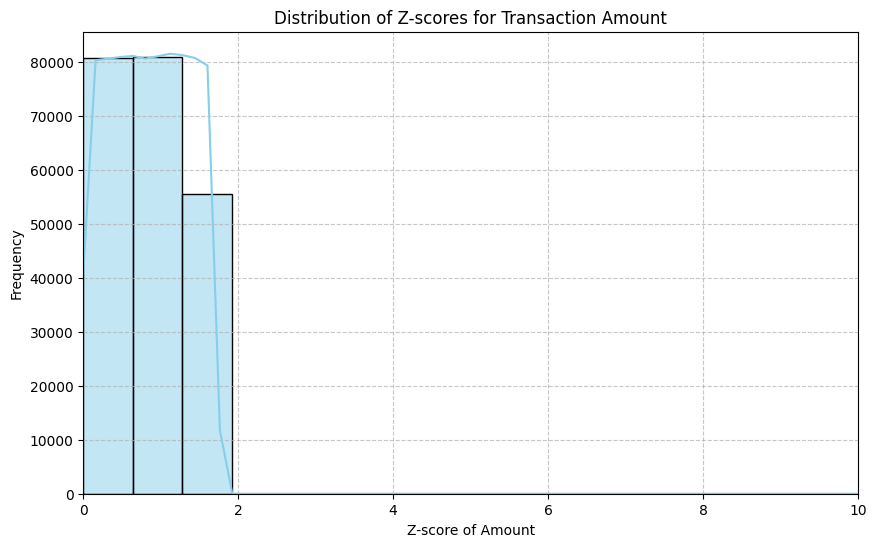

Number of potential anomalies (Z-score > 3): 11

First 5 potential anomalies based on Z-score:
               Timestamp     Amount  Amount_Zscore
2775 2023-03-01 06:15:00  978942.26      31.921619
3448 2023-03-01 17:28:00  712076.97      22.750330
3453 2023-03-01 17:33:00  489492.30      15.100822
4148 2023-04-01 05:08:00  187344.37       4.716984
4194 2023-04-01 05:54:00  272990.11       7.660348


In [22]:
df['Amount_Zscore'] = np.abs((df['Amount'] - df['Amount'].mean()) / df['Amount'].std())

plt.figure(figsize=(10, 6))
sns.histplot(df['Amount_Zscore'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Z-scores for Transaction Amount')
plt.xlabel('Z-score of Amount')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 10)
plt.show()

anomalies = df[df['Amount_Zscore'] > 3]
print(f"Number of potential anomalies (Z-score > 3): {len(anomalies)}")
print("\nFirst 5 potential anomalies based on Z-score:")
print(anomalies[['Timestamp', 'Amount', 'Amount_Zscore']].head())

### 3.2 Feature Selection & Data Splitting

In [23]:
numerical_features = ['Amount', 'Year', 'Month', 'Day', 'Hour', 'Minute', 'DayOfWeek', 'DayOfYear']
excluded_features = ['Timestamp', 'TransactionID', 'Amount_Zscore']

In [24]:
all_columns = df.columns.tolist()
features_for_modeling = [col for col in all_columns if col not in excluded_features]
X = df[features_for_modeling]
print(f"Number of features selected for modeling: {len(features_for_modeling)}")
print("First 5 rows of the feature DataFrame X:")
print(X.head())

Number of features selected for modeling: 37
First 5 rows of the feature DataFrame X:
     Amount  Year  Month  Day  Hour  Minute  DayOfWeek  DayOfYear  \
0  95071.92  2023      1    1     8       0          6          1   
1  15607.89  2023      1    1     8       1          6          1   
2  65092.34  2023      1    1     8       2          6          1   
3     87.87  2023      1    1     8       3          6          1   
4    716.56  2023      1    1     8       4          6          1   

   AccountID_ACC10  AccountID_ACC11  ...  Merchant_MerchantG  \
0            False            False  ...               False   
1             True            False  ...               False   
2            False            False  ...               False   
3            False            False  ...               False   
4            False            False  ...               False   

   Merchant_MerchantH  Merchant_MerchantI  Merchant_MerchantJ  \
0                True               False        

In [25]:
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

print(f"Shape of training data: {X_train.shape}")
print(f"Shape of testing data: {X_test.shape}")

Shape of training data: (173568, 37)
Shape of testing data: (43392, 37)


### 3.3 Model Building

#### GMM

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaled successfully.")
n_components_range = range(1, 11)
bic_scores = []
aic_scores = []

for k in n_components_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_train_scaled)
    bic_scores.append(gmm.bic(X_train_scaled))
    aic_scores.append(gmm.aic(X_train_scaled))

optimal_k_bic = n_components_range[np.argmin(bic_scores)]
print(f"Optimal number of components (k) based on BIC: {optimal_k_bic}")

gmm_optimal = GaussianMixture(n_components=optimal_k_bic, random_state=42)
gmm_optimal.fit(X_train_scaled)

gmm_scores_train = gmm_optimal.score_samples(X_train_scaled)
gmm_scores_test = gmm_optimal.score_samples(X_test_scaled)

print(f"GMM fitted with optimal k={optimal_k_bic} and log-likelihoods computed.")

Data scaled successfully.
Optimal number of components (k) based on BIC: 10
GMM fitted with optimal k=10 and log-likelihoods computed.


In [34]:
anomaly_percentile = 5
anomaly_threshold = np.percentile(gmm_scores_train, anomaly_percentile)

print(f"Anomaly threshold (log-likelihood at {anomaly_percentile}th percentile of training data): {anomaly_threshold:.2f}")

anomalies_train = gmm_scores_train < anomaly_threshold
anomalies_test = gmm_scores_test < anomaly_threshold

num_anomalies_train = np.sum(anomalies_train)
num_anomalies_test = np.sum(anomalies_test)

print(f"\nNumber of anomalies detected in training set: {num_anomalies_train}")
print(f"Number of anomalies detected in testing set: {num_anomalies_test}")

X_test_results = X_test.copy()
X_test_results['GMM_LogLikelihood'] = gmm_scores_test
X_test_results['Is_Anomaly'] = anomalies_test

anomaly_examples = X_test_results[X_test_results['Is_Anomaly']].sort_values(by='GMM_LogLikelihood').head(10)

print("\nExamples of detected anomalies from the testing set (lowest log-likelihoods):")
print(anomaly_examples[['Amount', 'GMM_LogLikelihood']])

Anomaly threshold (log-likelihood at 5th percentile of training data): 23.64

Number of anomalies detected in training set: 8679
Number of anomalies detected in testing set: 2213

Examples of detected anomalies from the testing set (lowest log-likelihoods):
           Amount  GMM_LogLikelihood
3448    712076.97        -232.375308
100379   91562.84          19.953559
146282   14736.93          20.331496
145027    7949.20          20.537460
146350   89495.83          20.553443
145017   68289.57          20.581967
189361   95746.88          20.583071
145144    8836.32          20.621178
101759   75068.77          20.700357
146399   44176.39          20.735110


In [33]:
gmm_anomalies_df = X_test_results[X_test_results['Is_Anomaly'] == True].reset_index().rename(columns={'index': 'Original_Index'})
gmm_anomalies_df.to_csv('gmm_anomalies.csv', index=False)
print(f"Successfully saved {len(gmm_anomalies_df)} GMM anomalies to 'gmm_anomalies.csv'.")
print("First 5 rows of GMM anomalies:")
print(gmm_anomalies_df.head())

Successfully saved 2213 GMM anomalies to 'gmm_anomalies.csv'.
First 5 rows of GMM anomalies:
   Original_Index    Amount  Year  Month  Day  Hour  Minute  DayOfWeek  \
0          100075  23737.90  2023     11    3    19      55          4   
1          188931  88802.95  2023     12    5    12      51          1   
2          206878   3117.16  2023      5   24    23      58          2   
3          178259  98674.99  2023      5    5     2      59          4   
4           77330   2241.28  2023      2   24     0      50          4   

   DayOfYear  AccountID_ACC10  ...  Merchant_MerchantI  Merchant_MerchantJ  \
0        307            False  ...               False               False   
1        339            False  ...               False                True   
2        144             True  ...               False               False   
3        125             True  ...               False               False   
4         55            False  ...               False               Fal

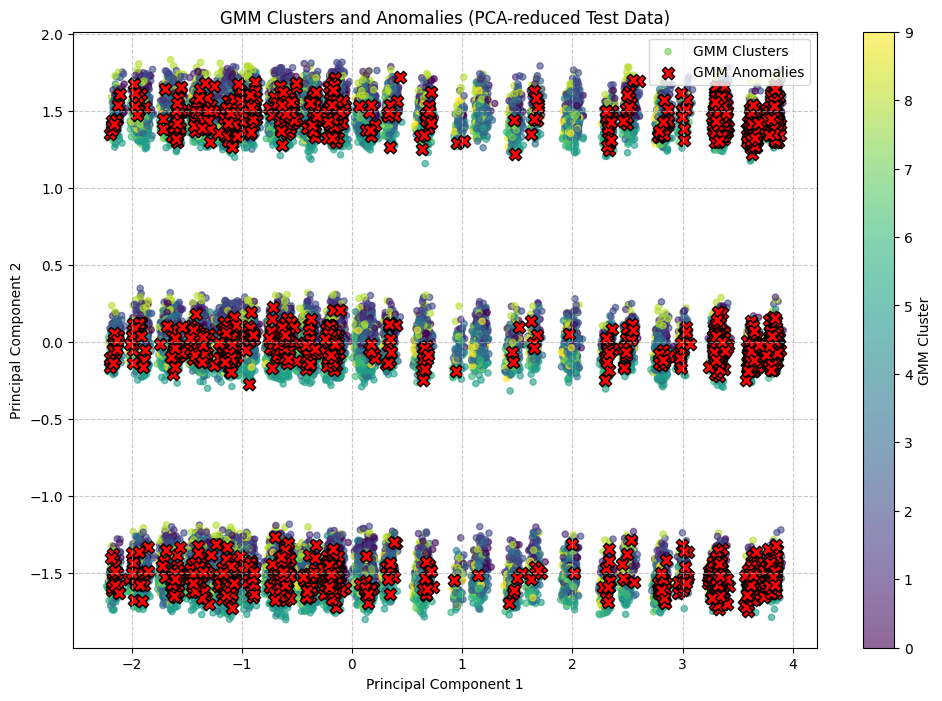

In [31]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_test_pca = pca.fit_transform(X_test_scaled)

gmm_clusters = gmm_optimal.predict(X_test_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_test_pca[:, 0],
                      X_test_pca[:, 1],
                      c=gmm_clusters,
                      cmap='viridis',
                      s=20,
                      alpha=0.6,
                      label='GMM Clusters')

# Corrected: Use the boolean mask 'anomalies_test' directly to index X_test_pca
plt.scatter(X_test_pca[anomalies_test, 0],
            X_test_pca[anomalies_test, 1],
            c='red',
            s=80,
            marker='X',
            label='GMM Anomalies',
            edgecolors='black')

plt.title('GMM Clusters and Anomalies (PCA-reduced Test Data)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
cbar = plt.colorbar(scatter)
cbar.set_label('GMM Cluster')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### Isolation Forest

In [ ]:
iso_forest = IsolationForest(n_estimators=100, max_samples='auto', contamination='auto', random_state=42)
iso_forest.fit(X_train_scaled)
if_scores_train = iso_forest.decision_function(X_train_scaled)
if_scores_test = iso_forest.decision_function(X_test_scaled)

print("Isolation Forest model fitted and anomaly scores computed successfully.")
print(f"First 5 anomaly scores for training data: {if_scores_train[:5]}")
print(f"First 5 anomaly scores for testing data: {if_scores_test[:5]}")

Isolation Forest model fitted and anomaly scores computed successfully.
First 5 anomaly scores for training data: [0.07697747 0.06444473 0.06839311 0.02397733 0.10265278]
First 5 anomaly scores for testing data: [0.04792897 0.02634995 0.05430885 0.06081631 0.06338037]


In [ ]:
anomaly_threshold_if = iso_forest.offset_

print(f"Anomaly threshold for Isolation Forest (offset_): {anomaly_threshold_if:.4f}")


anomalies_train_if = if_scores_train < anomaly_threshold_if
anomalies_test_if = if_scores_test < anomaly_threshold_if

num_anomalies_train_if = np.sum(anomalies_train_if)
num_anomalies_test_if = np.sum(anomalies_test_if)

print(f"\nNumber of anomalies detected by Isolation Forest in training set: {num_anomalies_train_if}")
print(f"Number of anomalies detected by Isolation Forest in testing set: {num_anomalies_test_if}")

X_test_results_if = X_test.copy()
X_test_results_if['IF_Anomaly_Score'] = if_scores_test
X_test_results_if['Is_Anomaly'] = anomalies_test_if

anomaly_examples_if = X_test_results_if[X_test_results_if['Is_Anomaly']].sort_values(by='IF_Anomaly_Score').head()

print("\nExamples of detected anomalies from the testing set by Isolation Forest (lowest anomaly scores):")
print(anomaly_examples_if[['Amount', 'IF_Anomaly_Score']])

Anomaly threshold for Isolation Forest (offset_): -0.5000

Number of anomalies detected by Isolation Forest in training set: 0
Number of anomalies detected by Isolation Forest in testing set: 0

Examples of detected anomalies from the testing set by Isolation Forest (lowest anomaly scores):
Empty DataFrame
Columns: [Amount, IF_Anomaly_Score]
Index: []


### 3.4 Model Evaluation

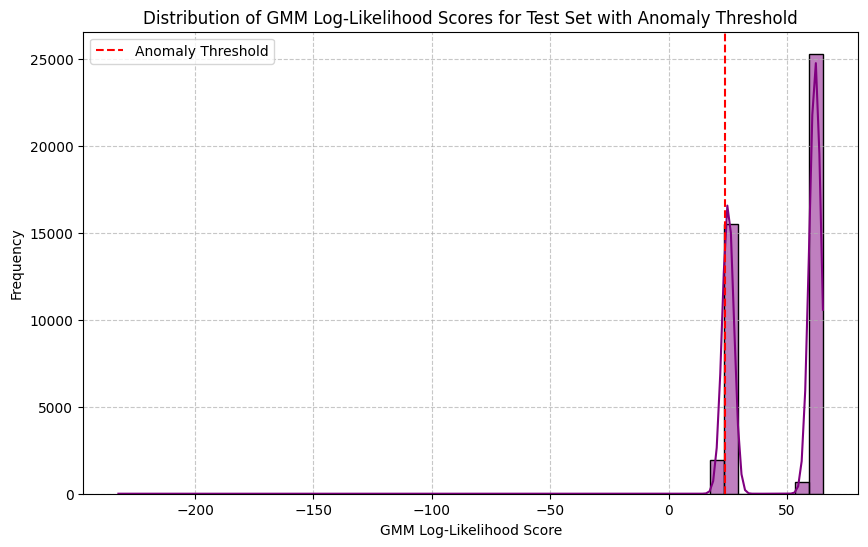

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(gmm_scores_test, bins=50, kde=True, color='purple')
plt.axvline(anomaly_threshold, color='red', linestyle='--', label='Anomaly Threshold')
plt.title('Distribution of GMM Log-Likelihood Scores for Test Set with Anomaly Threshold')
plt.xlabel('GMM Log-Likelihood Score')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

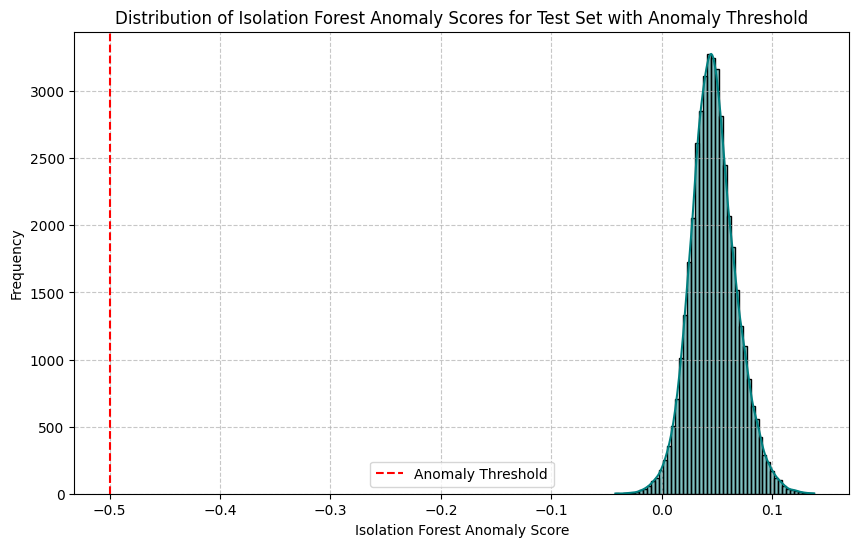

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(if_scores_test, bins=50, kde=True, color='teal')
plt.axvline(anomaly_threshold_if, color='red', linestyle='--', label='Anomaly Threshold')
plt.title('Distribution of Isolation Forest Anomaly Scores for Test Set with Anomaly Threshold')
plt.xlabel('Isolation Forest Anomaly Score')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Cross check

In [38]:
iso_df.shape

(3236, 10)

In [39]:
gmm_df.shape

(2213, 40)

In [40]:
iso_df = iso_df.rename(columns={'Unnamed: 0': 'Original_Index'})
iso_df.head()

,Original_Index,amount,merchant_te,location_te,transactiontype_te,merchant_le,location_le,transactiontype_le,IF_Anomaly,IF_score
0,29813,99765.47,50455.825346,50071.058024,50208.496692,8.0,0.0,0.0,1,-0.627823
1,50016,99652.33,50455.825346,50071.058024,50208.496692,8.0,0.0,0.0,1,-0.627610
2,46994,99482.18,50455.825346,50071.058024,50208.496692,8.0,0.0,0.0,1,-0.626126
3,28762,99248.55,50455.825346,50071.058024,50208.496692,8.0,0.0,0.0,1,-0.626126
4,23774,99405.06,50455.825346,50071.058024,50208.496692,8.0,0.0,0.0,1,-0.626126


In [42]:
common_anomalies = pd.merge(gmm_df, iso_df, on='Original_Index', how='inner')
print("First 5 rows of common_anomalies:")
print(common_anomalies.head())
print(f"\nShape of common_anomalies: {common_anomalies.shape}")

First 5 rows of common_anomalies:
   Original_Index    Amount  Year  Month  Day  Hour  Minute  DayOfWeek  \
0           51339  99811.98  2023      5    2    23      39          1   
1           47066   6902.80  2023      3    2     0      26          3   
2           44231  20435.56  2023      1    2     1      11          0   
3           47459  82170.93  2023      3    2     6      59          3   
4           61570  91421.11  2023      2   13     2      10          0   

   DayOfYear  AccountID_ACC10  ...  Is_Anomaly    amount   merchant_te  \
0        122            False  ...        True   1398.02  50353.160668   
1         61            False  ...        True  10672.65  50353.160668   
2          2             True  ...        True  83384.94  50353.160668   
3         61            False  ...        True   2916.88  49784.497070   
4         44            False  ...        True  22282.93  50353.160668   

    location_te  transactiontype_te  merchant_le  location_le  \
0  50188.35

In [43]:
num_common_anomalies = len(common_anomalies)
num_gmm_anomalies = len(gmm_df)
num_iso_anomalies = len(iso_df)

num_gmm_only_anomalies = num_gmm_anomalies - num_common_anomalies
num_iso_only_anomalies = num_iso_anomalies - num_common_anomalies

print(f"Number of common anomalies (identified by both models): {num_common_anomalies}")
print(f"Number of anomalies identified only by GMM: {num_gmm_only_anomalies}")
print(f"Number of anomalies identified only by Isolation Forest: {num_iso_only_anomalies}")

Number of common anomalies (identified by both models): 40
Number of anomalies identified only by GMM: 2173
Number of anomalies identified only by Isolation Forest: 3196
